In [5]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portfolio_data import load_asset_data
from classical_solver import brute_force_solver
from qubo_builder import build_qubo_matrix
from qaoa_solver import run_qaoa_solver

In [6]:
assets = load_asset_data("../data/sample_assets.csv")
assets

,asset,expected_return,risk
0,AAPL,0.08,0.12
1,MSFT,0.07,0.10
2,NVDA,0.15,0.22
3,TSLA,0.13,0.30
4,WMT,0.05,0.08
5,JPM,0.06,0.11


In [7]:
returns = assets["expected_return"].values

covariance = np.array([
    [0.12, 0.02, 0.03, 0.04, 0.01, 0.02],
    [0.02, 0.10, 0.02, 0.03, 0.01, 0.02],
    [0.03, 0.02, 0.22, 0.06, 0.02, 0.03],
    [0.04, 0.03, 0.06, 0.30, 0.02, 0.04],
    [0.01, 0.01, 0.02, 0.02, 0.08, 0.01],
    [0.02, 0.02, 0.03, 0.04, 0.01, 0.11],
])

k = 3

best_x, best_score, best_risk, best_return, results = brute_force_solver(
    returns,
    covariance,
    k
)

selected_assets = assets.loc[best_x == 1, "asset"].tolist()

print("Best bitstring:", "".join(str(i) for i in best_x))
print("Selected assets:", selected_assets)
print("Portfolio return:", best_return)
print("Portfolio risk:", best_risk)
print("Objective score:", best_score)

Best bitstring: 110010
Selected assets: ['AAPL', 'MSFT', 'WMT']
Portfolio return: 0.2
Portfolio risk: 0.38
Objective score: 0.18


In [8]:
results_df = pd.DataFrame(results)
results_df.sort_values("score").head(10)

,bitstring,score,risk,return
2,110010,0.18,0.38,0.20
15,010011,0.19,0.37,0.18
9,100011,0.20,0.39,0.19
11,011010,0.23,0.50,0.27
3,110001,0.24,0.45,0.21
5,101010,0.26,0.54,0.28
18,001011,0.27,0.53,0.26
0,111000,0.28,0.58,0.30
12,011001,0.29,0.57,0.28
6,101001,0.32,0.61,0.29


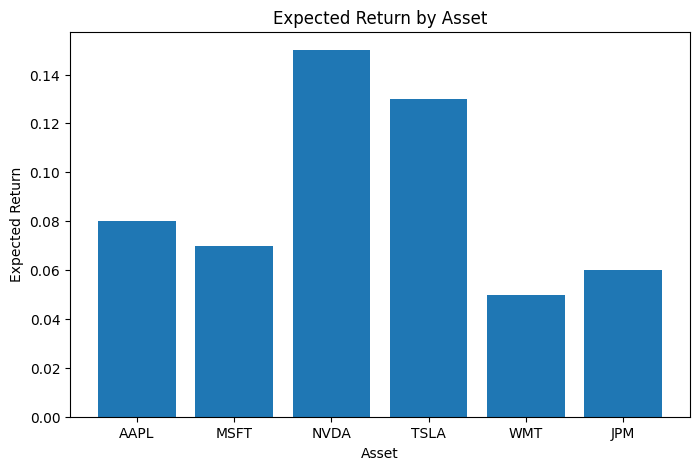

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(assets["asset"], assets["expected_return"])
plt.title("Expected Return by Asset")
plt.xlabel("Asset")
plt.ylabel("Expected Return")
plt.show()

In [10]:
qubo = build_qubo_matrix(returns, covariance, k)

print("QUBO Matrix:")
print(qubo)

QUBO Matrix:
[[-9.96  4.02  4.03  4.04  4.01  4.02]
 [ 0.02 -9.97  4.02  4.03  4.01  4.02]
 [ 0.03  0.02 -9.93  4.06  4.02  4.03]
 [ 0.04  0.03  0.06 -9.83  4.02  4.04]
 [ 0.01  0.01  0.02  0.02 -9.97  4.01]
 [ 0.02  0.02  0.03  0.04  0.01 -9.95]]


In [11]:
run_qaoa_solver(qubo)

QAOA solver will be added in the next step.
QUBO matrix received with size: (6, 6)
